### **Import Libraries**

In [85]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import pygris
import numpy as np
from weightedstats import weighted_median

### **Read In Data Set**

In [86]:
df = pd.read_csv("usa_00027.csv")
df.head()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,MET2013,GQ,OWNERSHP,OWNERSHPD,OWNCOST,RENTGRS,HHINCOME,UNITSSTR
0,2024,202401,1,2024010000060,41.0,2024000000011,0,3,0,0,99999,0,9999999,0
1,2024,202401,2,2024010000094,52.0,2024000000021,0,3,0,0,99999,0,9999999,0
2,2024,202401,3,2024010000146,31.0,2024000000031,13820,3,0,0,99999,0,9999999,0
3,2024,202401,4,2024010000156,4.0,2024000000041,33660,4,0,0,99999,0,9999999,0
4,2024,202401,5,2024010000182,19.0,2024000000051,11500,3,0,0,99999,0,9999999,0


### **Filter Dataset**

In [87]:
condition = (df["GQ"] == 1) & (df["MET2013"] > 0) &  (df["HHINCOME"] > 0) & (df["HHINCOME"] < 9999999)
df = df[condition]
df["MET2013"] = df["MET2013"].astype(str)

### **Cost Burdened**

In [88]:
df_cost = df.copy()
df_cost["monthly_cost"] = np.where(df_cost["OWNERSHP"] == 1, df_cost["OWNCOST"].replace(99999, np.nan),df_cost["RENTGRS"].replace(99999, np.nan))
df_cost["monthly_income"] = df_cost["HHINCOME"] / 12
df_cost["cost_burden"] = df_cost["monthly_cost"] / df_cost["monthly_income"]
df_cost["burdened_30"] = df_cost["cost_burden"] >= 0.30
df_cost["burdened_50"] = df_cost["cost_burden"] >= 0.50

### **Area Median Income**

/var/folders/3l/12mcyxkx38jdv4zv_hxngvtw0000gn/T/ipykernel_42589/1178610360.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ami_by_msa = df_cost.groupby("MET2013").apply(lambda x: weighted_median(x["HHINCOME"], weights=x["HHWT"])).reset_index()


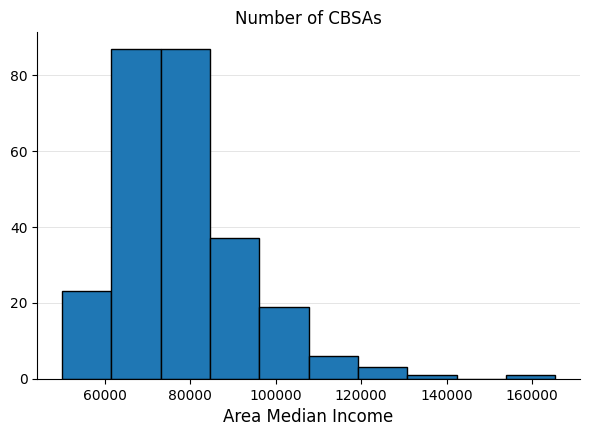

In [89]:
ami_by_msa = df_cost.groupby("MET2013").apply(lambda x: weighted_median(x["HHINCOME"], weights=x["HHWT"])).reset_index()
ami_by_msa.columns = ["MET2013", "AMI"]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.spines['top'].set_visible(False)                                                                                                                                                                 
ax.spines['right'].set_visible(False) 
ax.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.7, alpha=0.6)                                                                                                                       
ax.set_axisbelow(True) 
plt.hist(ami_by_msa['AMI'], edgecolor='black')
ax.set_title('Number of CBSAs')
ax.set_xlabel('Area Median Income', size=12)
plt.show()

### **Shape File**

In [90]:
msas = pygris.core_based_statistical_areas(year=2020)
states = pygris.states(year=2020)
msas.head()

,CSAFP,CBSAFP,GEOID,NAME,NAMELSAD,LSAD,MEMI,MTFCC,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,122,12020,12020,"Athens-Clarke County, GA","Athens-Clarke County, GA Metro Area",M1,1,G3110,2654607902,26109459,+33.9439840,-083.2138965,"POLYGON ((-83.53738 33.96591, -83.53184 33.968..."
1,122,12060,12060,"Atlanta-Sandy Springs-Alpharetta, GA","Atlanta-Sandy Springs-Alpharetta, GA Metro Area",M1,1,G3110,22495780629,386874693,+33.6937280,-084.3999113,"POLYGON ((-85.33823 33.65312, -85.33842 33.654..."
2,428,12100,12100,"Atlantic City-Hammonton, NJ","Atlantic City-Hammonton, NJ Metro Area",M1,1,G3110,1438774368,301270979,+39.4693555,-074.6337591,"POLYGON ((-74.85675 39.42076, -74.8567 39.4208..."
3,426,12120,12120,"Atmore, AL","Atmore, AL Micro Area",M2,2,G3110,2448595161,20024887,+31.1222867,-087.1684097,"POLYGON ((-87.61542 31.041, -87.61542 31.04116..."
4,258,12140,12140,"Auburn, IN","Auburn, IN Micro Area",M2,2,G3110,939731962,2657419,+41.3967596,-085.0026969,"POLYGON ((-85.19295 41.38001, -85.19296 41.381..."


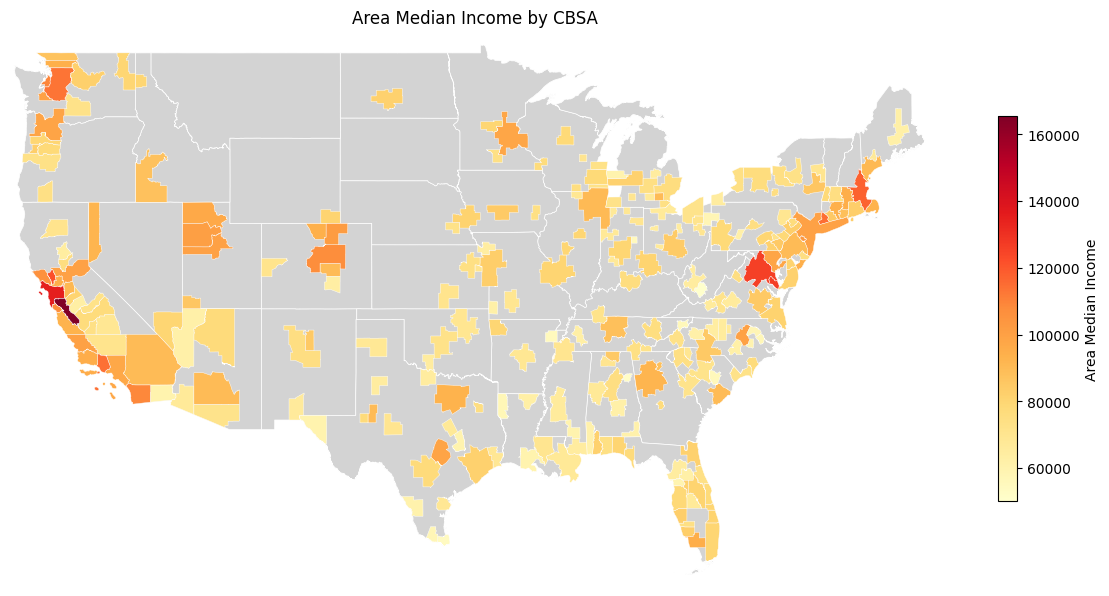

In [91]:
ami_by_msa["MET2013"] = ami_by_msa["MET2013"].astype(str)
msas["CBSAFP"] = msas["CBSAFP"].astype(str)
msas_plot = msas.merge(ami_by_msa, left_on="CBSAFP", right_on="MET2013", how="inner")

fig, ax = plt.subplots(figsize=(15, 10))
states.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
msas_plot.plot(
    column="AMI",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.3,
    legend_kwds={"label": "Area Median Income", "shrink": 0.5}
)
# Zoom to continental US
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")
ax.set_title("Area Median Income by CBSA")
plt.show()

In [92]:
df_cost = df_cost.merge(
    ami_by_msa,
    how="left",        
    on="MET2013",      
    validate="m:1",     
    indicator=True      
)

In [93]:

top_30 = (df_cost.groupby("MET2013")["HHWT"].sum().sort_values(ascending=False).head(30).index.tolist())
df_top30 = df_cost[df_cost["MET2013"].isin(top_30)]


def weighted_mean(x, col, weight="HHWT"):
    return (x[col] * x[weight]).sum() / x[weight].sum()

burden_rates = df_top30.groupby(["MET2013", "OWNERSHP"]).apply(
    lambda x: pd.Series({"burdened_30": weighted_mean(x, "burdened_30"), "burdened_50": weighted_mean(x, "burdened_50")})).reset_index()

# Pivot to wide format
owners = burden_rates[burden_rates["OWNERSHP"] == 1].set_index("MET2013")
renters = burden_rates[burden_rates["OWNERSHP"] == 2].set_index("MET2013")

/var/folders/3l/12mcyxkx38jdv4zv_hxngvtw0000gn/T/ipykernel_42589/11259996.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  burden_rates = df_top30.groupby(["MET2013", "OWNERSHP"]).apply(


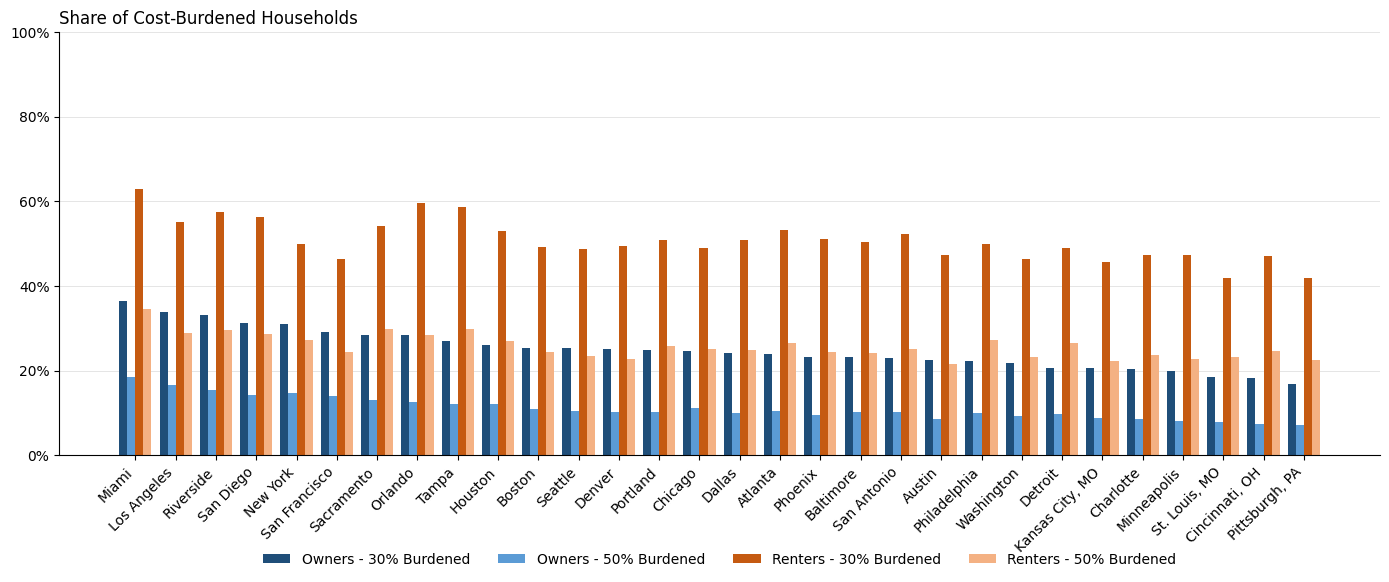

In [94]:
plot_df = pd.DataFrame({
    "owners_30": owners["burdened_30"],
    "owners_50": owners["burdened_50"],
    "renters_30": renters["burdened_30"],
    "renters_50": renters["burdened_50"]
})

plot_df = plot_df.reset_index()
plot_df["MET2013"] = plot_df["MET2013"].astype(str)
msas["CBSAFP"] = msas["CBSAFP"].astype(str)

plot_df = plot_df.merge(
    msas[["CBSAFP", "NAME"]], 
    left_on="MET2013", 
    right_on="CBSAFP",
    how="left"
)

plot_df["NAME"] = plot_df["NAME"].str.replace(r"-.*$", "", regex=True)
plot_df = plot_df.set_index("NAME")

plot_df = plot_df.sort_values("owners_30", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.spines['top'].set_visible(False)                                                                                                                                                                 
ax.spines['right'].set_visible(False) 
ax.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.7, alpha=0.6)                                                                                                                       
ax.set_axisbelow(True) 
x = np.arange(len(plot_df))
width = 0.2

ax.bar(x - 1.5*width, plot_df["owners_30"], width, label="Owners - 30% Burdened", color="#1f4e79")
ax.bar(x - 0.5*width, plot_df["owners_50"], width, label="Owners - 50% Burdened", color="#5b9bd5")
ax.bar(x + 0.5*width, plot_df["renters_30"], width, label="Renters - 30% Burdened", color="#c55a11")
ax.bar(x + 1.5*width, plot_df["renters_50"], width, label="Renters - 50% Burdened", color="#f4b183")

ax.set_title("Share of Cost-Burdened Households", loc='left')
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()

In [113]:
df_cost['MaxHousing'] = (df_cost["HHINCOME"] / 12)*.3
bins = range(10_000, 200_000, 25_000)
results = []
for low, high in zip(bins[:-1], bins[1:]):
    print(low, high)
    subset = df_cost[df_cost["HHINCOME"].between(low, high, inclusive="left")]
    total_households = subset["HHWT"].sum()
    max_housing = subset["MaxHousing"].max()
    min_housing = subset["MaxHousing"].min()
    total_available_houses = df_cost[df_cost["monthly_cost"].between(min_housing, max_housing, inclusive="left")]["HHWT"].sum()
    shortage = total_households - total_available_houses
    results.append(shortage)

fig, ax = plt.subplots()
plt.plot(bins[1:], results)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))
plt.show()

10000 35000
-5065723.0
35000 60000
-8957441.0
60000 85000
-7181565.0
85000 110000
-1438321.0
110000 135000
1894626.0
135000 160000
2822442.0
160000 185000
2856559.0


In [ ]:
bins = list(range(10_000, 200_000, 25_000))
results = []
for threshold 

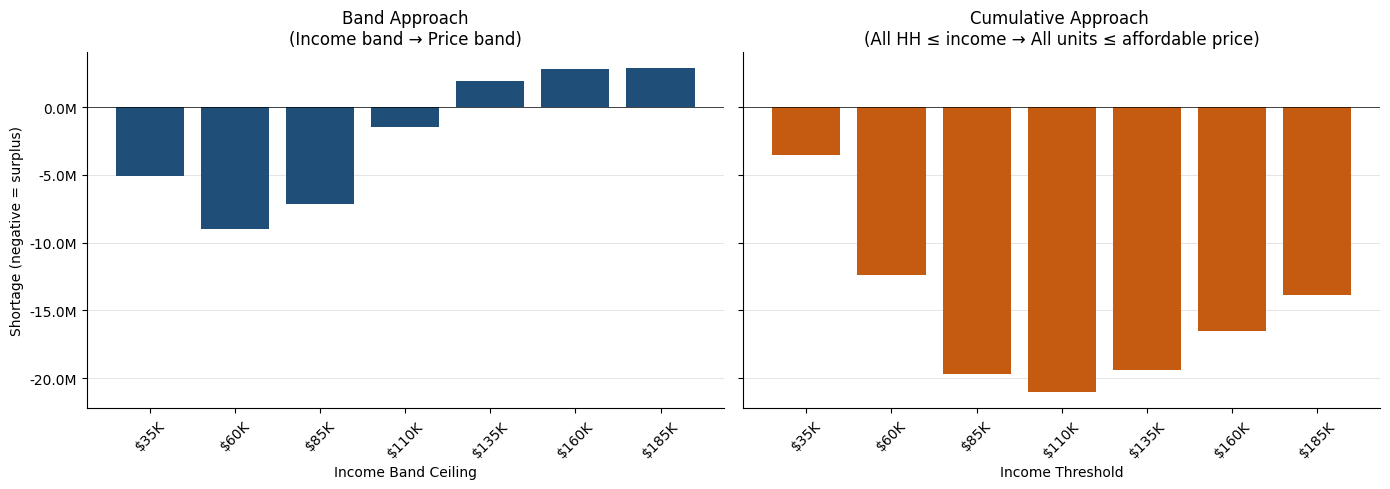

In [126]:
bins = list(range(10_000, 200_000, 25_000))
band_results = []
cumulative_results = []

# Band approach: each income band matched to corresponding price band
for low, high in zip(bins[:-1], bins[1:]):
    subset = df_cost[df_cost["HHINCOME"].between(low, high, inclusive="left")]
    total_households = subset["HHWT"].sum()
    
    min_housing = (low / 12) *.3
    max_housing = (high / 12) * 0.3
    total_units = df_cost[df_cost["monthly_cost"].between(min_housing, max_housing, inclusive="left")]["HHWT"].sum()
    
    band_results.append(total_households - total_units)

# Cumulative approach: all households below threshold vs all units below affordable price
for threshold in bins[1:]:
    max_affordable = (threshold / 12) * 0.3
    
    total_households = df_cost[df_cost["HHINCOME"] <= threshold]["HHWT"].sum()
    total_units = df_cost[df_cost["monthly_cost"] <= max_affordable]["HHWT"].sum()
    
    cumulative_results.append(total_households - total_units)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Band approach
axes[0].bar([f"${b//1000}K" for b in bins[1:]], band_results, color="#1f4e79")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Band Approach\n(Income band → Price band)")
axes[0].set_xlabel("Income Band Ceiling")
axes[0].set_ylabel("Shortage (negative = surplus)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines['top'].set_visible(False)                                                                                                                                                                 
axes[0].spines['right'].set_visible(False) 
axes[0].grid(axis='y', color='lightgray', linestyle='-', linewidth=0.7, alpha=0.6) 
axes[0].set_axisbelow(True) 

# Cumulative approach
axes[1].bar([f"${b//1000}K" for b in bins[1:]], cumulative_results, color="#c55a11")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Cumulative Approach \n(All HH ≤ income → All units ≤ affordable price)")
axes[1].set_xlabel("Income Threshold")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines['top'].set_visible(False)                                                                                                                                                                 
axes[1].spines['right'].set_visible(False) 
axes[1].grid(axis='y', color='lightgray', linestyle='-', linewidth=0.7, alpha=0.6) 
axes[1].set_axisbelow(True) 

plt.tight_layout()
plt.show()

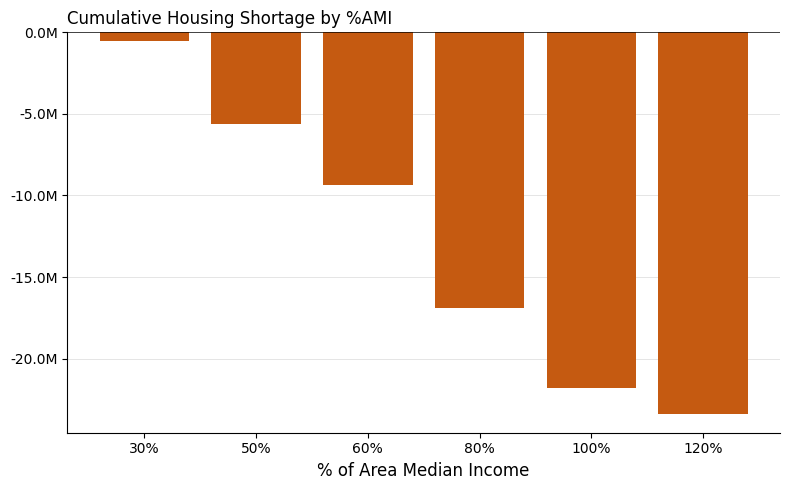

In [132]:
ami_thresholds = [30, 50, 60, 80, 100, 120]
results = []

for msa in df_cost["MET2013"].unique():
    msa_data = df_cost[df_cost["MET2013"] == msa]
    ami = msa_data["AMI"].iloc[0]
    
    for pct in ami_thresholds:
        income_threshold = ami * (pct / 100)
        max_affordable = (income_threshold / 12) * 0.3
        
        # Households at or below this %AMI
        total_hh = msa_data[msa_data["HHINCOME"] <= income_threshold]["HHWT"].sum()
        
        # Units priced at or below affordable level
        total_units = msa_data[msa_data["monthly_cost"] <= max_affordable]["HHWT"].sum()
        
        results.append({
            "MET2013": msa,
            "pct_ami": pct,
            "households": total_hh,
            "units": total_units,
            "shortage": total_hh - total_units
        })

shortage_df = pd.DataFrame(results)

# Aggregate nationally by %AMI
national = shortage_df.groupby("pct_ami").agg({
    "households": "sum",
    "units": "sum",
    "shortage": "sum"
}).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f"{p}%" for p in national["pct_ami"]], national["shortage"], color="#c55a11")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("% of Area Median Income", size=12)
ax.set_title("Cumulative Housing Shortage by %AMI", loc='left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))
ax.spines['top'].set_visible(False)                                                                                                                                                                 
ax.spines['right'].set_visible(False) 
ax.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.7, alpha=0.6) 
ax.set_axisbelow(True) 
plt.tight_layout()
plt.show()